# Mendeley OA — Download, Process & Inventory

**Dataset:** Knee Osteoarthritis Dataset with Severity Grading  
**Source:** Mendeley Data `t9ndx37v5h` / Kaggle `shashwatwork/knee-osteoarthritis-dataset-with-severity`  
**Reference:** [14] in thesis exposé  

---

## ⚠️ HOLD-OUT ONLY — DO NOT TRAIN ON THIS DATASET

Under the **leave-one-dataset-out (LODO)** evaluation protocol, Mendeley OA is
reserved **exclusively** for the final external evaluation run.  
It is **never** used for training or validation, and **no** train/val/test split
is produced here — only a single `mendeley_holdout.csv`.

---

### What this notebook does
1. Downloads the dataset via the Kaggle API (≈ 1.1 GB ZIP)
2. Extracts to `/content/mendeley_raw/`
3. Applies the unified preprocessing pipeline: CLAHE → 224×224 resize
4. Saves processed PNGs to `/content/drive/MyDrive/mendeley_oa/processed/`
5. Builds `mendeley_holdout.csv` (columns: `filename, kl_grade, source_split, dataset`)
6. Plots the KL distribution

### Dataset structure (original)
```
train/
  0/  1/  2/  3/  4/     ← KL grades
test/
  0/  1/  2/  3/  4/
val/
  0/  1/  2/  3/  4/
```
Images are pre-cropped individual knee X-rays (already bilateral-split).

In [1]:

from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:

import sys, subprocess
for pkg in ['kaggle', 'opencv-python-headless']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
print('Packages ready.')

Packages ready.


In [ ]:

import os, shutil, json
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

KAGGLE_DATASET  = 'shashwatwork/knee-osteoarthritis-dataset-with-severity'
RAW_DIR         = Path('/content/mendeley_raw')

DRIVE_ROOT      = Path('/content/drive/MyDrive')
PROJECT         = DRIVE_ROOT / 'Master Thesis'

OUT_DIR         = PROJECT / 'mendeley_oa' / 'processed'
LABEL_DIR       = PROJECT / 'mendeley_oa'

IMG_SIZE        = 224
CLAHE_CLIP      = 2.0
CLAHE_TILE      = (8, 8)
DATASET_TAG     = 'mendeley'

GRADE_FOLDERS = ['0', '1', '2', '3', '4']

SOURCE_SPLITS = ['train', 'test', 'val']

for d in [RAW_DIR, OUT_DIR, LABEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'RAW_DIR  : {RAW_DIR}')
print(f'OUT_DIR  : {OUT_DIR}')
print(f'LABEL_DIR: {LABEL_DIR}')


RAW_DIR  : /content/mendeley_raw
OUT_DIR  : /content/drive/MyDrive/mendeley_oa/processed
LABEL_DIR: /content/drive/MyDrive/mendeley_oa


## Kaggle credentials

Place your `kaggle.json` API token at one of these locations (checked in order):

1. **On Google Drive** (recommended — reusable across sessions):  
   `/content/drive/MyDrive/kaggle.json`

2. **Colab file uploader** (one-time per session):  
   Run the upload cell below instead.

Get your token at: https://www.kaggle.com/settings → **API** → **Create New Token**

In [4]:

KAGGLE_JSON_DRIVE = Path('/content/drive/MyDrive/kaggle.json')
KAGGLE_JSON_LOCAL = Path('/root/.config/kaggle/kaggle.json')

if KAGGLE_JSON_DRIVE.exists():
    KAGGLE_JSON_LOCAL.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(KAGGLE_JSON_DRIVE, KAGGLE_JSON_LOCAL)
    KAGGLE_JSON_LOCAL.chmod(0o600)
    print(f'Kaggle credentials loaded from Drive → {KAGGLE_JSON_LOCAL}')
elif KAGGLE_JSON_LOCAL.exists():
    print(f'Kaggle credentials already present at {KAGGLE_JSON_LOCAL}')
else:
    print('kaggle.json not found. Running interactive upload ...')
    from google.colab import files
    uploaded = files.upload()
    KAGGLE_JSON_LOCAL.parent.mkdir(parents=True, exist_ok=True)
    content = list(uploaded.values())[0]
    KAGGLE_JSON_LOCAL.write_bytes(content)
    KAGGLE_JSON_LOCAL.chmod(0o600)
    print(f'Uploaded and saved to {KAGGLE_JSON_LOCAL}')

with open(KAGGLE_JSON_LOCAL) as f:
    creds = json.load(f)
assert 'username' in creds and 'key' in creds, 'kaggle.json missing username or key'
print(f'Kaggle user: {creds["username"]}')

kaggle.json not found. Running interactive upload ...


Saving Kaggle.JSON to Kaggle.JSON
Uploaded and saved to /root/.config/kaggle/kaggle.json
Kaggle user: samihamrounilol


In [5]:

import kaggle

zip_marker = RAW_DIR / '.download_complete'

if zip_marker.exists():
    print(f'Dataset already downloaded and extracted to {RAW_DIR}')
else:
    print(f'Downloading {KAGGLE_DATASET} ...')
    kaggle.api.dataset_download_files(
        KAGGLE_DATASET,
        path=str(RAW_DIR),
        unzip=True,
        quiet=False,
    )
    zip_marker.touch()
    print('Download and extraction complete.')

print('\nTop-level contents of RAW_DIR:')
for p in sorted(RAW_DIR.iterdir()):
    if p.is_dir():
        n = sum(1 for _ in p.rglob('*') if _.is_file())
        print(f'  {p.name}/  ({n:,} files)')
    else:
        print(f'  {p.name}')

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity


100%|██████████| 204M/204M [00:01<00:00, 126MB/s]



Download and extraction complete.

Top-level contents of RAW_DIR:
  .download_complete
  auto_test/  (1,526 files)
  test/  (1,656 files)
  train/  (5,778 files)
  val/  (826 files)


In [6]:


def discover_images(root: Path):
    """Walk root and collect (file_path, kl_grade, source_split) tuples."""
    records = []
    image_exts = {'.png', '.jpg', '.jpeg', '.bmp'}

    for child in sorted(root.iterdir()):
        if not child.is_dir():
            continue

        if child.name in ('train', 'test', 'val', 'Train', 'Test', 'Val'):
            split_name = child.name.lower()
            grade_root = child
        elif child.name in GRADE_FOLDERS:
            split_name = 'all'
            grade_root = root
        else:
            continue

        for grade_folder in sorted(grade_root.iterdir()):
            if not grade_folder.is_dir() or grade_folder.name not in GRADE_FOLDERS:
                continue
            kl = int(grade_folder.name)
            for img_path in sorted(grade_folder.iterdir()):
                if img_path.suffix.lower() in image_exts:
                    records.append({
                        'raw_path'    : img_path,
                        'kl_grade'   : kl,
                        'source_split': split_name,
                    })

        if split_name == 'all':
            break

    return records

records = discover_images(RAW_DIR)
print(f'Total images discovered: {len(records):,}')

tmp = pd.DataFrame(records).drop(columns='raw_path')
print('\nImages per source_split × kl_grade:')
print(tmp.groupby(['source_split', 'kl_grade']).size().unstack(fill_value=0))

Total images discovered: 8,260

Images per source_split × kl_grade:
kl_grade         0     1     2    3    4
source_split                            
test           639   296   447  223   51
train         2286  1046  1516  757  173
val            328   153   212  106   27


In [7]:


clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

def process_image(raw_path: Path, out_path: Path) -> bool:
    """Load, preprocess, and save one image. Returns True on success."""
    try:
        img = cv2.imread(str(raw_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            return False
        img = clahe.apply(img)
        pil = Image.fromarray(img).resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        pil.save(out_path, format='PNG')
        return True
    except Exception as e:
        print(f'  ERROR {raw_path.name}: {e}')
        return False

processed = []
errors    = []

for rec in tqdm(records, desc='Processing images'):
    raw_path     = rec['raw_path']
    kl           = rec['kl_grade']
    split        = rec['source_split']
    out_filename = f'Mendeley_{split}_KL{kl}_{raw_path.stem}.png'
    out_path     = OUT_DIR / out_filename

    if out_path.exists():
        processed.append({'filename': out_filename, 'kl_grade': kl, 'source_split': split})
        continue

    ok = process_image(raw_path, out_path)
    if ok:
        processed.append({'filename': out_filename, 'kl_grade': kl, 'source_split': split})
    else:
        errors.append(raw_path)

print(f'\nProcessed : {len(processed):,}')
print(f'Errors    : {len(errors):,}')
if errors:
    print('Failed files:')
    for p in errors[:10]:
        print(f'  {p}')

Processing images:   0%|          | 0/8260 [00:00<?, ?it/s]


Processed : 8,260
Errors    : 0


In [8]:


holdout_df = pd.DataFrame(processed)
holdout_df['dataset'] = DATASET_TAG

csv_path = LABEL_DIR / 'mendeley_holdout.csv'
holdout_df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}  ({len(holdout_df):,} rows)')
print('\nColumns:', holdout_df.columns.tolist())
print('\nSample rows:')
print(holdout_df.head(3).to_string(index=False))

print('\nKL grade distribution (all Mendeley images):')
print(holdout_df['kl_grade'].value_counts().sort_index())

Saved: /content/drive/MyDrive/mendeley_oa/mendeley_holdout.csv  (8,260 rows)

Columns: ['filename', 'kl_grade', 'source_split', 'dataset']

Sample rows:
                      filename  kl_grade source_split  dataset
Mendeley_test_KL0_9003175L.png         0         test mendeley
Mendeley_test_KL0_9003175R.png         0         test mendeley
Mendeley_test_KL0_9003316L.png         0         test mendeley

KL grade distribution (all Mendeley images):
kl_grade
0    3253
1    1495
2    2175
3    1086
4     251
Name: count, dtype: int64


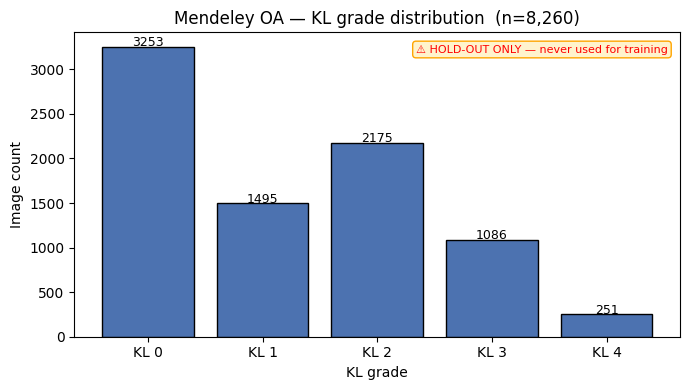

Plot saved: /content/drive/MyDrive/mendeley_oa/mendeley_kl_distribution.png


In [9]:

fig, ax = plt.subplots(figsize=(7, 4))

kl_counts = holdout_df['kl_grade'].value_counts().sort_index()
kl_labels = [f'KL {i}' for i in kl_counts.index]

bars = ax.bar(kl_labels, kl_counts.values, color='#4C72B0', edgecolor='black')
ax.set_title(f'Mendeley OA — KL grade distribution  (n={len(holdout_df):,})', fontsize=12)
ax.set_xlabel('KL grade')
ax.set_ylabel('Image count')
for bar, v in zip(bars, kl_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(v), ha='center', fontsize=9)

ax.text(0.98, 0.96, '⚠ HOLD-OUT ONLY — never used for training',
        transform=ax.transAxes, ha='right', va='top',
        color='red', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3cd', edgecolor='orange'))

plt.tight_layout()
plot_path = LABEL_DIR / 'mendeley_kl_distribution.png'
plt.savefig(plot_path, dpi=120)
plt.show()
print(f'Plot saved: {plot_path}')

## Summary

| Item | Value |
|---|---|
| Processed PNGs | see Cell 7 output |
| Hold-out CSV | `mendeley_oa/mendeley_holdout.csv` |
| Distribution plot | `mendeley_oa/mendeley_kl_distribution.png` |
| Dataset role | **Hold-out only (LODO evaluation)** |

